<a href="https://colab.research.google.com/github/san9roy/Urban-Development/blob/main/Urban_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

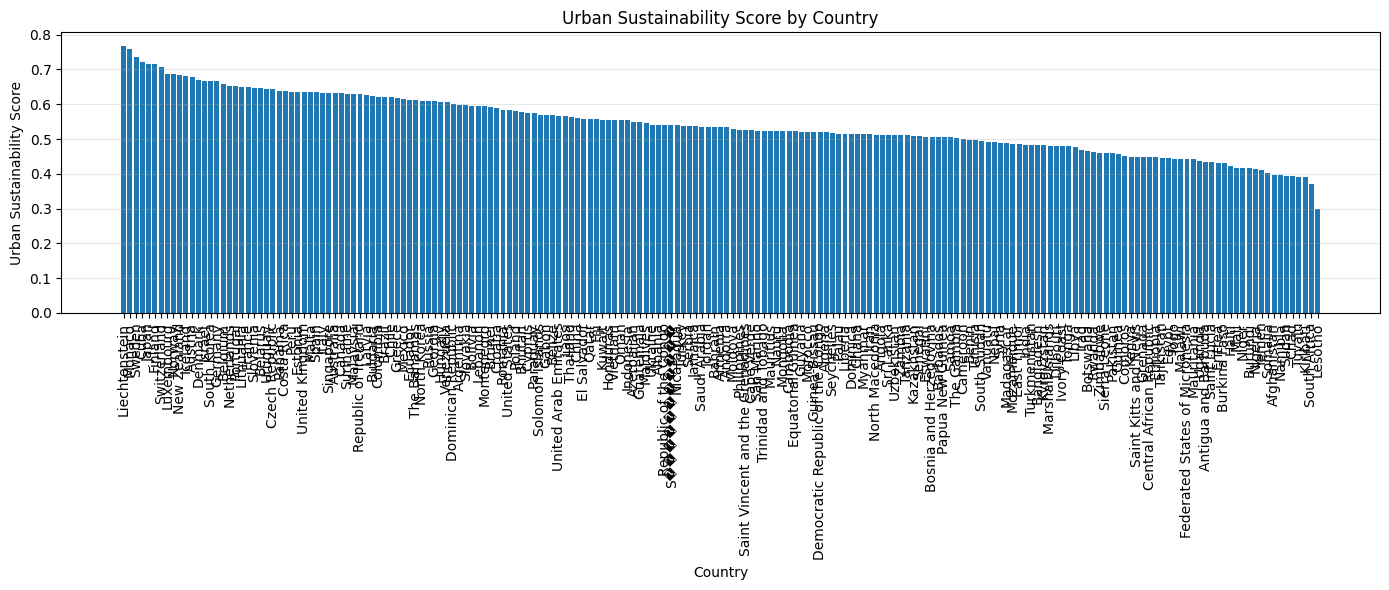

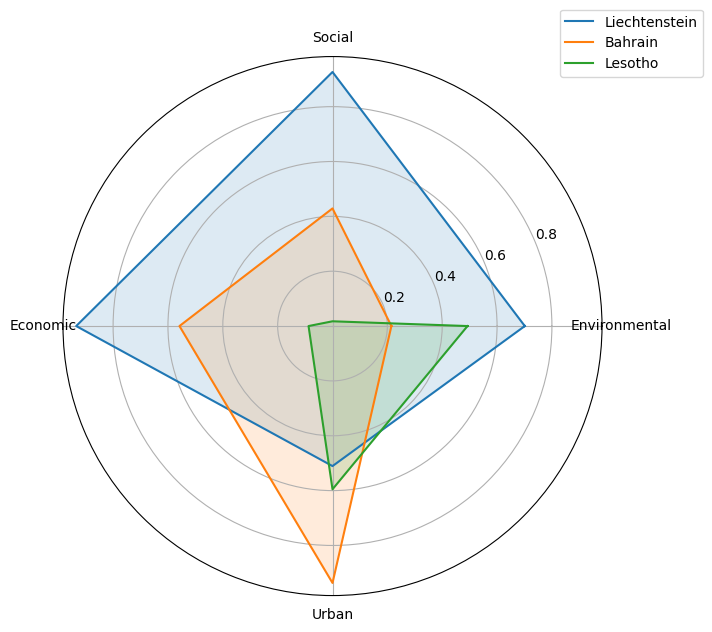

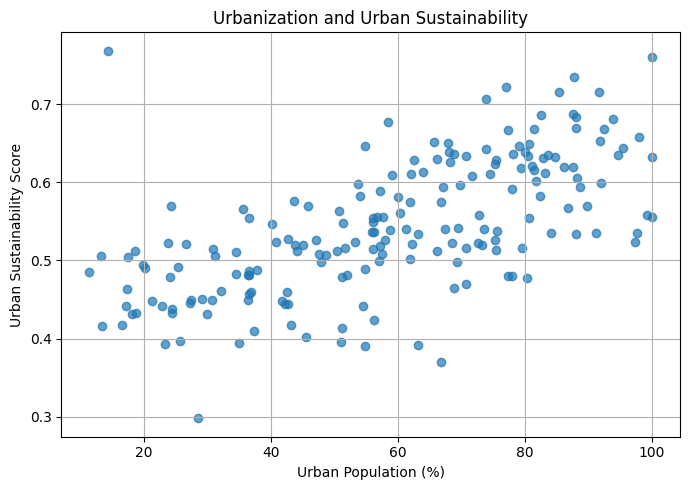

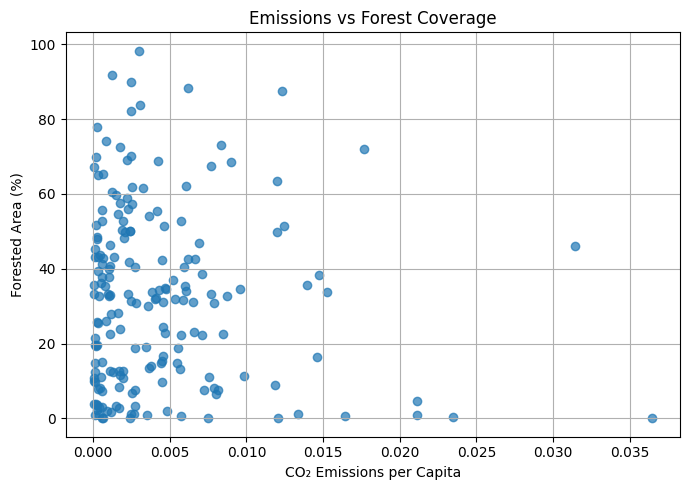

In [17]:
# ==========================================================
# Urban Sustainability Index (USI) for Different Cities in 2023
# ==========================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import geopandas as gpd

# =========================
# 1. Load Dataset
# =========================

BASE_DIR = Path.cwd()

possible_paths = [
    BASE_DIR / "data" / "world-data-2023.csv",
    BASE_DIR / "world-data-2023.csv",
    BASE_DIR.parent / "data" / "world-data-2023.csv",
]

for path in possible_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError("world-data-2023.csv not found")

df = pd.read_csv(DATA_PATH)

# =========================
# 2. Clean Column Names
# =========================

df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("/", "_", regex=False)
    .str.replace(r"[()%]", "", regex=True)
)

# =========================
# 3. Detect Columns
# =========================

def find_col(keywords):
    for col in df.columns:
        if any(k in col for k in keywords):
            return col
    return None

country = find_col(["country"])
population = find_col(["population"])
co2 = find_col(["co2"])
forest = find_col(["forest"])
life = find_col(["life_expectancy"])
physicians = find_col(["physicians"])
gdp = find_col(["gdp"])
unemployment = find_col(["unemployment"])
urban = find_col(["urban_population"])
land_area = find_col(["land_area"])

df = df[
    [
        country, population, co2, forest, life,
        physicians, gdp, unemployment, urban, land_area
    ]
].copy()

# =========================
# 4.Numeric Cleaning
# =========================

def clean_numeric(series):
    cleaned = (
        series.astype(str)
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace(r"[^\d\.\-]", "", regex=True)
    )

    cleaned = cleaned.replace(
        {"": np.nan, ".": np.nan, "-": np.nan, "--": np.nan}
    )

    return pd.to_numeric(cleaned, errors="coerce")

for col in df.columns:
    if col != country:
        df[col] = clean_numeric(df[col])

# =========================
# 5. Feature Engineering
# =========================

df["co2_per_capita"] = df[co2] / df[population]
df["gdp_per_capita"] = df[gdp] / df[population]
df["urban_population_pct"] = (df[urban] / df[population]) * 100
df["density"] = df[population] / df[land_area]

# CRITICAL FIX
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# =========================
# 6. Indicator Groups
# =========================

environmental = ["co2_per_capita", forest]
social = [life, physicians]
economic = ["gdp_per_capita", unemployment]
urban_dim = ["urban_population_pct", "density"]

negative_indicators = {"co2_per_capita", unemployment, "density"}
all_indicators = environmental + social + economic + urban_dim

# =========================
# 7. Normalization
# =========================

scaler = MinMaxScaler()
norm_cols = {}

for col in all_indicators:
    valid = df[[col]].dropna()
    if len(valid) > 5:
        norm_col = f"{col}_norm"
        df.loc[valid.index, norm_col] = scaler.fit_transform(valid)
        if col in negative_indicators:
            df.loc[valid.index, norm_col] = 1 - df.loc[valid.index, norm_col]
        norm_cols[col] = norm_col

# =========================
# 8. Dimension Scores
# =========================

def dimension_score(indicators):
    cols = [norm_cols[i] for i in indicators if i in norm_cols]
    return df[cols].mean(axis=1)

df["environmental_score"] = dimension_score(environmental)
df["social_score"] = dimension_score(social)
df["economic_score"] = dimension_score(economic)
df["urban_score"] = dimension_score(urban_dim)

# =========================
# 9. Urban Sustainability Index
# =========================

df["urban_sustainability_score"] = df[
    ["environmental_score", "social_score", "economic_score", "urban_score"]
].mean(axis=1)

# =========================
# 10. Visualizations
# =========================

# ---- Bar Chart: Sustainability Score ----
bar_df = (
    df[[country, "urban_sustainability_score"]]
    .dropna()
    .sort_values("urban_sustainability_score", ascending=False)
)

plt.figure(figsize=(14, 6))
plt.bar(bar_df[country], bar_df["urban_sustainability_score"])
plt.xticks(rotation=90)
plt.ylabel("Urban Sustainability Score")
plt.xlabel("Country")
plt.title("Urban Sustainability Score by Country")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


# ---- Radar Plot: Top / Median / Bottom ----
valid = df.dropna(
    subset=[
        "environmental_score",
        "social_score",
        "economic_score",
        "urban_score",
    ]
).sort_values("urban_sustainability_score", ascending=False)

def radar_plot(countries):
    labels = ["Environmental", "Social", "Economic", "Urban"]
    angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))
    for c in countries:
        r = valid[valid[country] == c].iloc[0]
        values = [
            r["environmental_score"],
            r["social_score"],
            r["economic_score"],
            r["urban_score"],
        ]
        values += values[:1]
        ax.plot(angles, values, label=c)
        ax.fill(angles, values, alpha=0.15)

    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.legend(loc="upper right", bbox_to_anchor=(1.2, 1.1))
    plt.show()

if len(valid) >= 3:
    radar_plot([
        valid.iloc[0][country],
        valid.iloc[len(valid)//2][country],
        valid.iloc[-1][country],
    ])


# ---- Urbanization vs Sustainability ----
plt.figure(figsize=(7, 5))
plt.scatter(
    df["urban_population_pct"],
    df["urban_sustainability_score"],
    alpha=0.7
)
plt.xlabel("Urban Population (%)")
plt.ylabel("Urban Sustainability Score")
plt.title("Urbanization and Urban Sustainability")
plt.grid(True)
plt.tight_layout()
plt.show()


# ---- Environmental Trade-offs ----
plt.figure(figsize=(7, 5))
plt.scatter(
    df["co2_per_capita"],
    df[forest],
    alpha=0.7
)
plt.xlabel("CO₂ Emissions per Capita")
plt.ylabel("Forested Area (%)")
plt.title("Emissions vs Forest Coverage")
plt.grid(True)
plt.tight_layout()
plt.show()
